# Analyse de la performance des employés

**Auteur :** BOUKAR Sadjo Doubla
**Objectif :** identifier les facteurs associés à la performance des employés, construire un score de performance global, et segmenter les employés en profils homogènes par clustering.

**Données :** `Employee_Complete_Dataset.csv` — 50 000 employés, 19 variables (informations professionnelles : salaire, expérience, satisfaction, équilibre vie professionnelle/personnelle, etc.).

> **Note méthodologique :** le dataset contient également des variables personnelles (statut marital, nombre d'enfants, situation des parents). Ces variables n'ont pas de lien légitime avec la performance professionnelle et ne sont volontairement pas exploitées dans cette analyse, par souci de rigueur méthodologique et pour éviter tout biais discriminatoire dans une analyse RH.

## Plan
1. Chargement et exploration des données
2. Analyse univariée des variables de performance
3. Performance par département et par rôle
4. Analyse des corrélations
5. Construction d'un score de performance global
6. Segmentation des employés par clustering (K-Means)
7. Conclusion

## 1. Chargement et exploration des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("Employee_Complete_Dataset.csv")
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (50000, 19)


,Employee_number,Employee_name,Employee_age,Maritial_Status,Current_Salary,Number_of_Children,years_experience,past_projects,current_projects,Divorced_earlier,Father_alive,Mother_alive,performance_rating,Education_level,Department,Role,Job_Satisfaction,Work_Life_Balance,is_outlier
0,10001,Karen Anderson,36,True,116138,2,12,6,1,No,Yes,Yes,3,Bachelor's,R&D,Researcher,10.000000,1.936454,0
1,10002,David Taylor,34,False,82171,3,10,5,0,Yes,Yes,No,5,Diploma,HR,HR Executive,10.000000,4.077728,0
2,10003,Nina Kumar,36,False,48600,1,0,2,3,Yes,Yes,Yes,4,Diploma,Sales,Sales Manager,10.000000,3.975622,0
3,10004,John Patel,42,True,39675,1,2,4,2,Yes,Yes,Yes,3,Diploma,Engineering,Software Engineer,1.000000,3.790951,0
4,10005,Emily Sharma,27,True,161304,3,3,11,2,Yes,Yes,Yes,2,High School,R&D,Scientist,8.251833,10.000000,0


In [3]:
print("Types de données :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum().sum(), "valeurs manquantes au total")

Types de données :
Employee_number         int64
Employee_name             str
Employee_age            int64
Maritial_Status          bool
Current_Salary          int64
Number_of_Children      int64
years_experience        int64
past_projects           int64
current_projects        int64
Divorced_earlier          str
Father_alive              str
Mother_alive              str
performance_rating      int64
Education_level           str
Department                str
Role                      str
Job_Satisfaction      float64
Work_Life_Balance     float64
is_outlier              int64
dtype: object

Valeurs manquantes :
0 valeurs manquantes au total


Le dataset inclut un indicateur `is_outlier` signalant des employés aux profils atypiques (valeurs extrêmes). On les exclut pour ne pas fausser les moyennes et le clustering.

In [4]:
print("Employés marqués comme outliers :", df["is_outlier"].sum())
df = df[df["is_outlier"] == 0].copy()
print("Dimensions après exclusion :", df.shape)

Employés marqués comme outliers : 714
Dimensions après exclusion : (49286, 19)


In [5]:
performance_vars = ["performance_rating", "Job_Satisfaction", "Work_Life_Balance",
                     "Current_Salary", "years_experience", "past_projects", "current_projects"]
df[performance_vars].describe()

,performance_rating,Job_Satisfaction,Work_Life_Balance,Current_Salary,years_experience,past_projects,current_projects
count,49286.000000,49286.000000,49286.000000,49286.000000,49286.000000,49286.000000,49286.000000
mean,3.198434,6.556683,4.520189,57716.967902,8.260114,7.017652,1.501177
std,0.981531,2.971453,2.860168,26095.587051,8.553164,4.324554,1.115483
min,1.000000,1.000000,1.000000,30000.000000,0.000000,0.000000,0.000000
25%,3.000000,4.179881,1.974837,33614.250000,0.000000,3.000000,1.000000
50%,3.000000,6.874691,4.040643,52993.500000,6.000000,7.000000,2.000000
75%,4.000000,9.786681,6.604555,73615.000000,14.000000,11.000000,2.000000
max,5.000000,10.000000,10.000000,200000.000000,44.000000,14.000000,3.000000


## 2. Analyse univariée des variables de performance

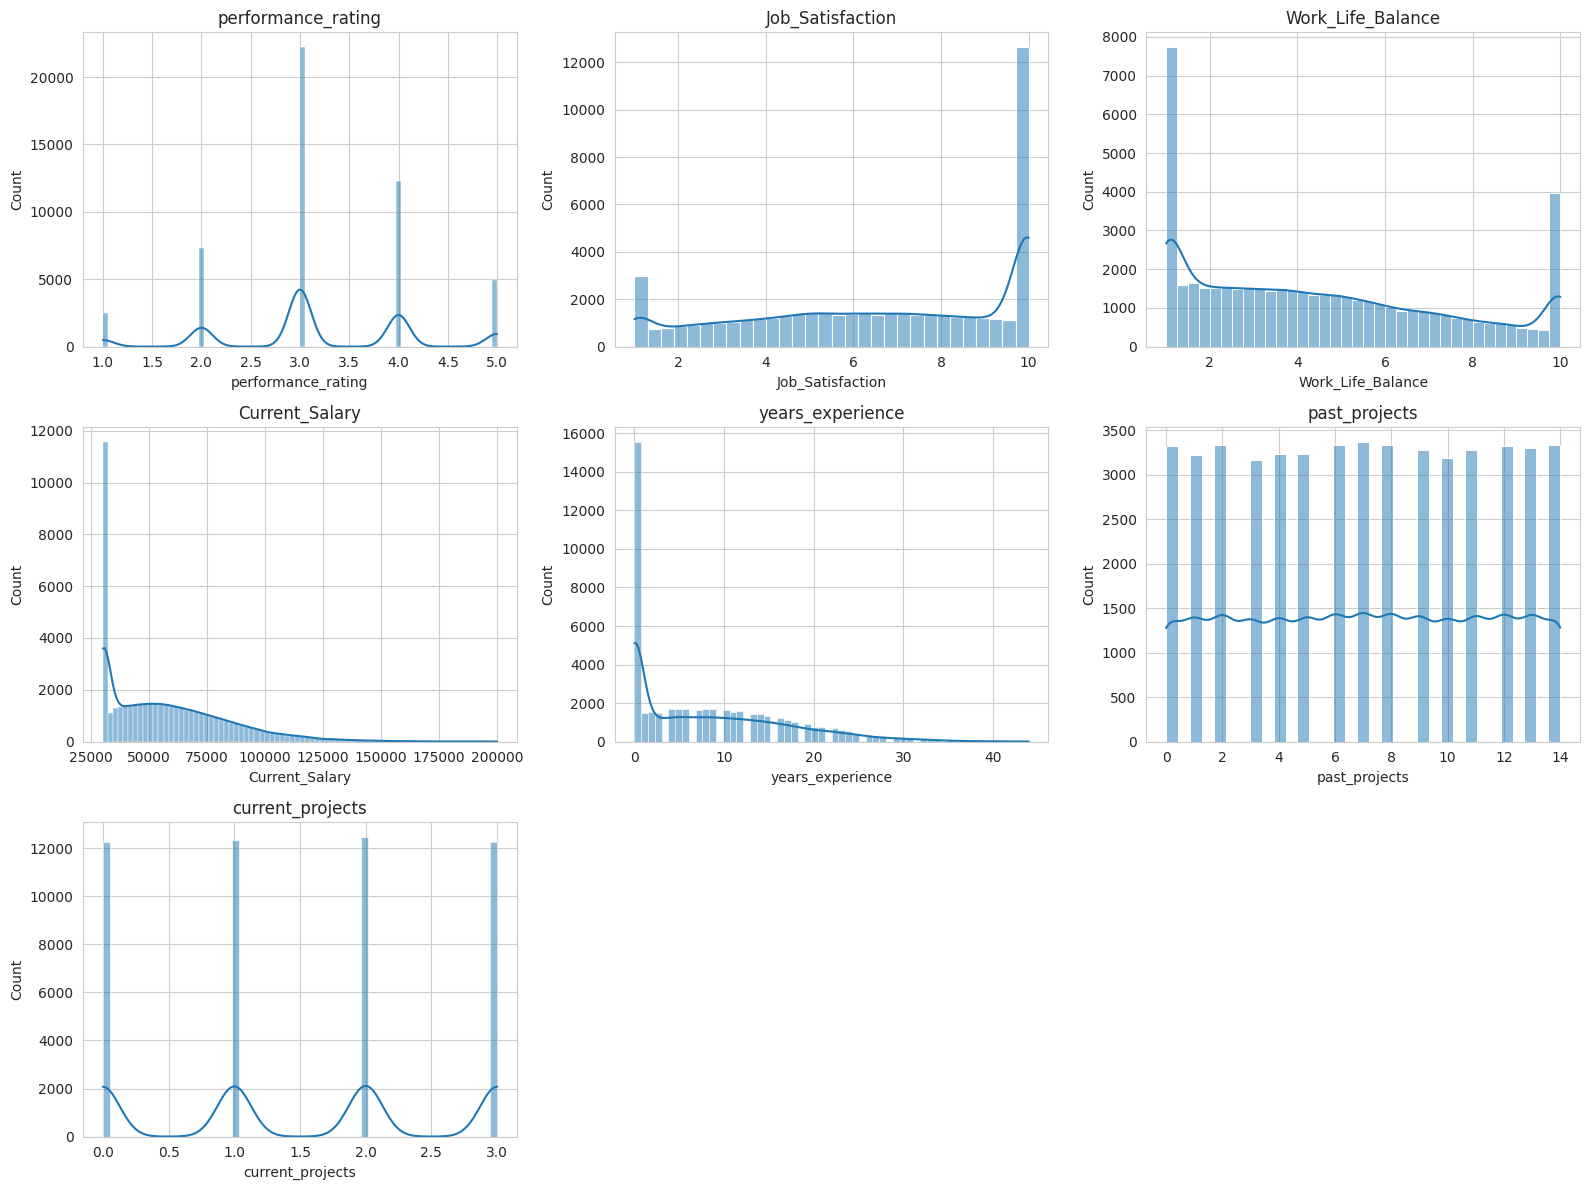

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(performance_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(performance_vars), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Les notes de performance sont concentrées entre 3 et 4 (sur 5), avec une distribution relativement symétrique. Le salaire et l'expérience montrent des distributions plus étalées, cohérentes avec une population d'employés à différents stades de carrière.

## 3. Performance par département et par rôle

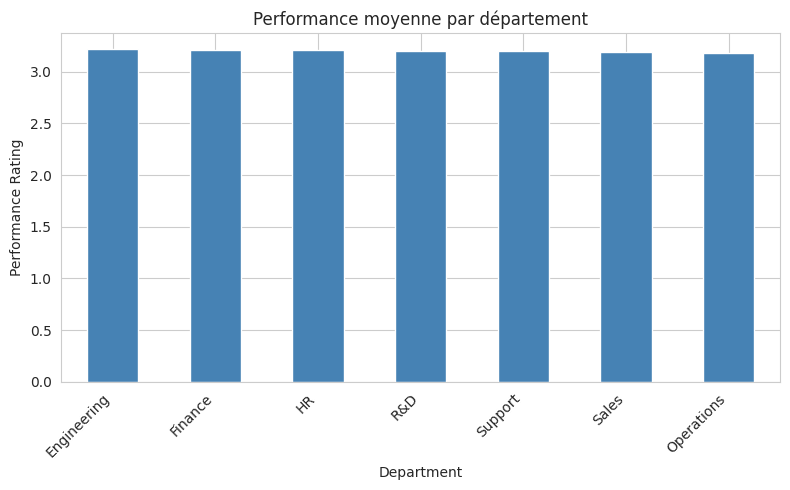

Department
Engineering    3.213358
Finance        3.210818
HR             3.203669
R&D            3.196824
Support        3.196326
Sales          3.185336
Operations     3.182930
Name: performance_rating, dtype: float64

In [7]:
dept_perf = df.groupby("Department")["performance_rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
dept_perf.plot(kind="bar", color="steelblue")
plt.title("Performance moyenne par département")
plt.ylabel("Performance Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
dept_perf

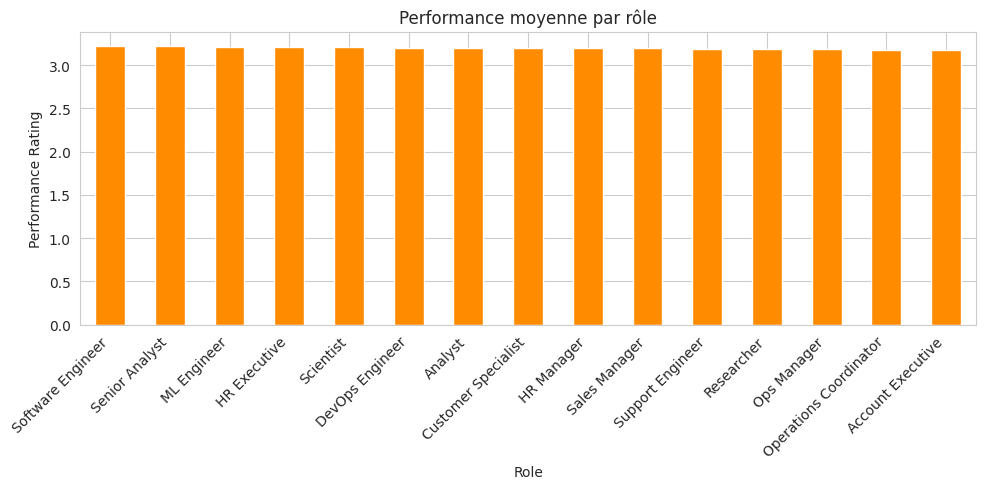

Role
Software Engineer         3.224604
Senior Analyst            3.219799
ML Engineer               3.213040
HR Executive              3.212331
Scientist                 3.206282
DevOps Engineer           3.202118
Analyst                   3.202023
Customer Specialist       3.201796
HR Manager                3.195094
Sales Manager             3.193303
Support Engineer          3.190863
Researcher                3.187156
Ops Manager               3.185122
Operations Coordinator    3.180730
Account Executive         3.177365
Name: performance_rating, dtype: float64

In [8]:
role_perf = df.groupby("Role")["performance_rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
role_perf.plot(kind="bar", color="darkorange")
plt.title("Performance moyenne par rôle")
plt.ylabel("Performance Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
role_perf

Les écarts de performance moyenne entre départements et rôles sont faibles (moins de 0.1 point sur une échelle de 5), ce qui suggère que la performance ne dépend pas fortement de l'appartenance à un département ou un rôle donné — d'autres facteurs individuels jouent probablement un rôle plus important.

## 4. Analyse des corrélations

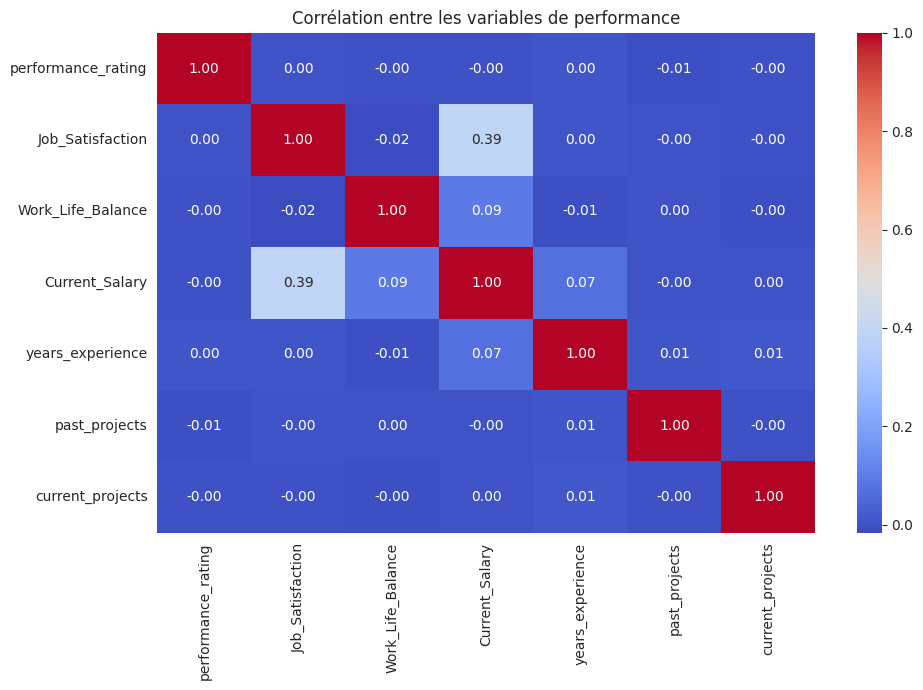

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[performance_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre les variables de performance")
plt.tight_layout()
plt.show()

Aucune corrélation forte ne se dégage entre les variables numériques disponibles et la note de performance : le salaire, l'expérience et le nombre de projets ne sont pas, à eux seuls, de bons prédicteurs de la performance individuelle dans ce dataset.

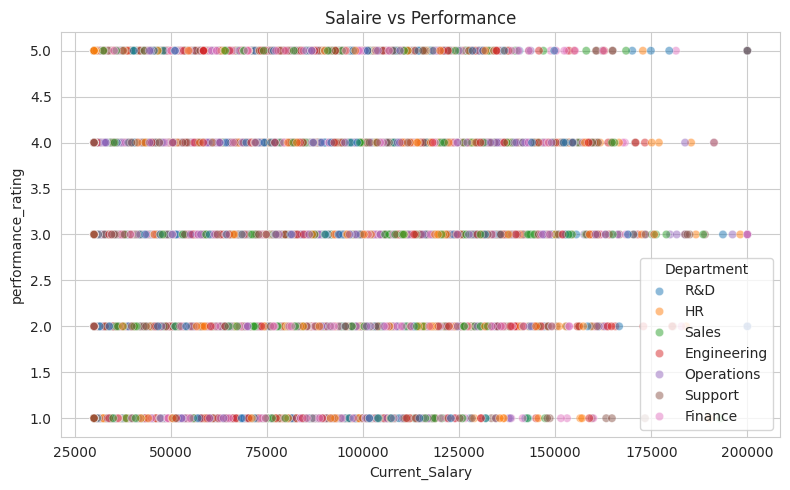

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Current_Salary", y="performance_rating", hue="Department", data=df, alpha=0.5)
plt.title("Salaire vs Performance")
plt.tight_layout()
plt.show()

## 5. Construction d'un score de performance global

On combine trois indicateurs en un score unique, pondéré pour refléter à la fois l'évaluation managériale (`performance_rating`) et le ressenti de l'employé (`Job_Satisfaction`, `Work_Life_Balance`) :

`Score = 0.4 × performance_rating + 0.3 × Job_Satisfaction + 0.3 × Work_Life_Balance`

In [11]:
df["Global_Performance_Score"] = (df["performance_rating"] * 0.4 +
                                    df["Job_Satisfaction"] * 0.3 +
                                    df["Work_Life_Balance"] * 0.3)

top10 = df[["Employee_name", "Department", "Role", "Global_Performance_Score"]].sort_values(
    by="Global_Performance_Score", ascending=False).head(10)
print("Top 10 employés les plus performants :")
top10

Top 10 employés les plus performants :


,Employee_name,Department,Role,Global_Performance_Score
39855,Rohit Gupta,Operations,Operations Coordinator,8.0
17910,Karen Thompson,Finance,Analyst,8.0
39888,Daniel Lewis,Engineering,DevOps Engineer,8.0
8035,Michael Miller,Sales,Sales Manager,8.0
36200,Luke Miller,R&D,Researcher,8.0
26743,Karen Williams,Finance,Senior Analyst,8.0
29559,David Kumar,Support,Support Engineer,8.0
14359,Kiran Walker,Support,Support Engineer,8.0
16480,Priya Taylor,Support,Support Engineer,8.0
11693,John Patel,Finance,Analyst,8.0


## 6. Segmentation des employés par clustering (K-Means)

On segmente les employés en 3 profils à partir de leur score global, leur salaire et leur expérience, après standardisation des variables (nécessaire car ces trois variables ont des échelles très différentes).

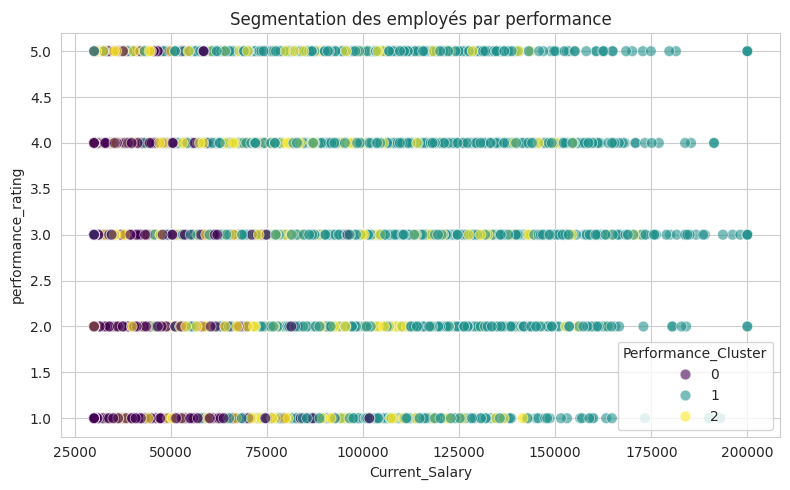

In [12]:
cluster_features = ["Global_Performance_Score", "Current_Salary", "years_experience"]
X = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Performance_Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Current_Salary", y="performance_rating", hue="Performance_Cluster",
                data=df, palette="viridis", s=60, alpha=0.6)
plt.title("Segmentation des employés par performance")
plt.tight_layout()
plt.show()

In [13]:
cluster_summary = df.groupby("Performance_Cluster")[cluster_features].mean()
cluster_counts = df["Performance_Cluster"].value_counts().sort_index()
print("Résumé par cluster :")
print(cluster_summary)
print("\nEffectifs par cluster :")
print(cluster_counts)

Résumé par cluster :
                     Global_Performance_Score  Current_Salary  \
Performance_Cluster                                             
0                                    3.707486    40395.366106   
1                                    5.547866    77110.068981   
2                                    4.668353    57433.054030   

                     years_experience  
Performance_Cluster                    
0                            4.163708  
1                            4.555099  
2                           20.009506  

Effectifs par cluster :
Performance_Cluster
0    19437
1    17541
2    12308
Name: count, dtype: int64


**Interprétation des 3 profils identifiés :**

- **Cluster junior / performance modérée** : salaire et score de performance plus bas, ancienneté faible.
- **Cluster haute performance** : meilleur score de performance global et salaire plus élevé, ancienneté moyenne — probablement des employés à fort potentiel ou récemment promus.
- **Cluster senior** : ancienneté nettement supérieure (environ 20 ans), score de performance intermédiaire, salaire intermédiaire — profil d'employés expérimentés mais dont la progression salariale ne suit pas nécessairement la performance.

Ce dernier point mérite une attention RH particulière : une forte ancienneté sans progression de performance ni de salaire proportionnelle peut être un signal de désengagement à surveiller.

## 7. Conclusion

- La performance individuelle ne semble pas fortement déterminée par le département, le rôle ou le salaire seuls : les écarts moyens entre groupes sont faibles.
- Le score de performance global combiné permet de mieux distinguer les employés que la seule note managériale.
- Le clustering révèle trois profils RH actionnables, en particulier un groupe d'employés expérimentés dont la performance et la rémunération n'augmentent pas avec l'ancienneté — une piste à creuser pour la rétention des talents.

**Limites :** l'analyse est purement descriptive et ne permet pas d'établir de causalité. Une étude plus poussée (régression multivariée, contrôle des facteurs confondants) serait nécessaire pour identifier les véritables leviers de la performance.

In [14]:
df.to_csv("employee_performance_enriched.csv", index=False)
print("Fichier enrichi sauvegardé : employee_performance_enriched.csv")

Fichier enrichi sauvegardé : employee_performance_enriched.csv
